<a href="https://colab.research.google.com/github/fossti/ml_practice/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%E2%84%9613_%D0%93%D0%B5%D0%BE%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%8D%D0%BA%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D1%84%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

In [1]:
!pip -q install osmnx h3 geopandas shapely leafmap

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import h3
import leafmap

from shapely.geometry import Point, Polygon
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

city_name = "Уфа, Россия"

city = ox.geocode_to_gdf(city_name).to_crs(4326)
city_polygon = city.geometry.iloc[0]

tags_pollution = {
    "landuse": ["industrial", "landfill"],
    "man_made": ["works"],
    "power": ["plant"],
    "amenity": ["recycling", "waste_transfer_station"]
}

tags_green = {
    "leisure": ["park", "garden", "nature_reserve"],
    "landuse": ["forest", "grass", "recreation_ground"]
}

tags_water = {
    "natural": ["water"],
    "waterway": ["river", "stream", "canal"]
}

tags_roads = {
    "highway": ["motorway", "trunk", "primary", "secondary"]
}

pollution = ox.features_from_polygon(city_polygon, tags_pollution)
green = ox.features_from_polygon(city_polygon, tags_green)
water = ox.features_from_polygon(city_polygon, tags_water)
roads = ox.features_from_polygon(city_polygon, tags_roads)

pollution = pollution.reset_index()
green = green.reset_index()
water = water.reset_index()
roads = roads.reset_index()

pollution = gpd.GeoDataFrame(pollution, geometry="geometry", crs=4326)
green = gpd.GeoDataFrame(green, geometry="geometry", crs=4326)
water = gpd.GeoDataFrame(water, geometry="geometry", crs=4326)
roads = gpd.GeoDataFrame(roads, geometry="geometry", crs=4326)

print("Территория:", city_name)
print("Источники загрязнения:", len(pollution))
print("Зеленые территории:", len(green))
print("Водные объекты:", len(water))
print("Автомагистрали:", len(roads))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 1

### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [2]:
resolution = 8

cells = h3.geo_to_cells(city_polygon, resolution)

hexagons = []

for cell in cells:
    boundary = h3.cell_to_boundary(cell)
    polygon = Polygon([(lng, lat) for lat, lng in boundary])
    hexagons.append(polygon)

grid = gpd.GeoDataFrame(
    {"h3_cell": cells},
    geometry=hexagons,
    crs=4326
)

grid["center"] = grid.geometry.centroid
centers = gpd.GeoDataFrame(
    grid[["h3_cell"]].copy(),
    geometry=grid.geometry.centroid,
    crs=4326
)

grid_metric = grid.to_crs(3857)
centers_metric = centers.to_crs(3857)

pollution_metric = pollution.to_crs(3857)
green_metric = green.to_crs(3857)
water_metric = water.to_crs(3857)
roads_metric = roads.to_crs(3857)

grid_metric["pollution_count"] = 0
grid_metric["green_area"] = 0.0
grid_metric["water_length"] = 0.0
grid_metric["road_length"] = 0.0

for i, point in enumerate(centers_metric.geometry):

    buffer_1600 = point.buffer(1600)
    buffer_800 = point.buffer(800)

    pollution_mask = pollution_metric.geometry.intersects(buffer_1600)
    grid_metric.loc[i, "pollution_count"] = pollution_mask.sum()

    green_intersection = green_metric[
        green_metric.geometry.intersects(buffer_800)
    ]

    if len(green_intersection) > 0:
        green_area = green_intersection.geometry.intersection(buffer_800).area.sum()
    else:
        green_area = 0

    grid_metric.loc[i, "green_area"] = green_area

    water_intersection = water_metric[
        water_metric.geometry.intersects(buffer_1600)
    ]

    if len(water_intersection) > 0:
        water_length = water_intersection.geometry.intersection(buffer_1600).length.sum()
    else:
        water_length = 0

    grid_metric.loc[i, "water_length"] = water_length

    roads_intersection = roads_metric[
        roads_metric.geometry.intersects(buffer_1600)
    ]

    if len(roads_intersection) > 0:
        road_length = roads_intersection.geometry.intersection(buffer_1600).length.sum()
    else:
        road_length = 0

    grid_metric.loc[i, "road_length"] = road_length

grid_metric["green_percent"] = (
    grid_metric["green_area"] /
    np.pi / 800**2 * 100
)

grid_metric["pollution_density"] = (
    grid_metric["pollution_count"] /
    (np.pi * 1600**2 / 1_000_000)
)

grid_metric["road_density"] = (
    grid_metric["road_length"] /
    (np.pi * 1600**2 / 1_000_000)
)

feature_columns = [
    "pollution_density",
    "green_percent",
    "water_length",
    "road_density"
]

features = grid_metric[feature_columns].copy()

features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(0)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

grid_metric["ecological_index"] = (
    -scaled_features[:, 0]
    + scaled_features[:, 1]
    + scaled_features[:, 2]
    - scaled_features[:, 3]
)

grid_metric = grid_metric.reset_index(drop=True)

grid = grid_metric.to_crs(4326)

grid["center"] = grid.geometry.centroid

print("Количество H3-ячеек:", len(grid))
display(grid[feature_columns + ["ecological_index"]].head())

Количество H3-ячеек: 810


,pollution_density,green_percent,water_length,road_density,ecological_index
0,0.373019,0.000000,11144.997678,731.705737,-1.281190
1,1.119058,0.109844,180.147026,656.533034,-5.634256
2,0.124340,0.000000,5742.431600,754.251779,-1.109058
3,0.124340,0.653281,10099.614715,0.000000,1.036157
4,0.124340,0.000000,5431.825388,771.343093,-1.185605


### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

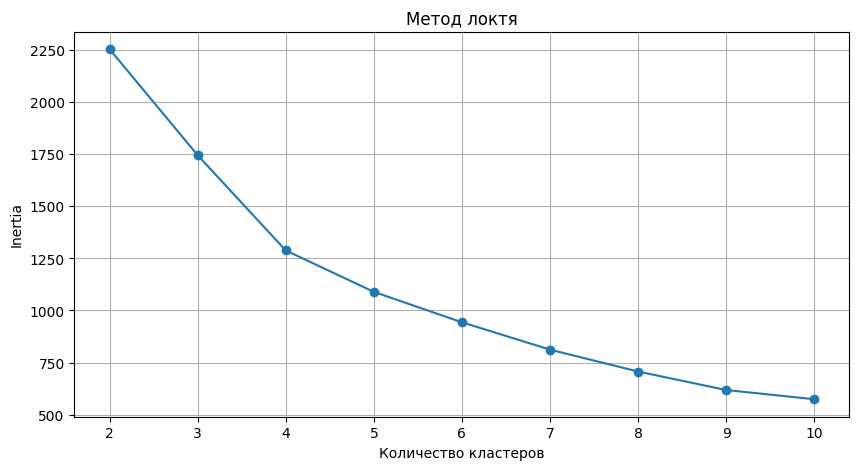

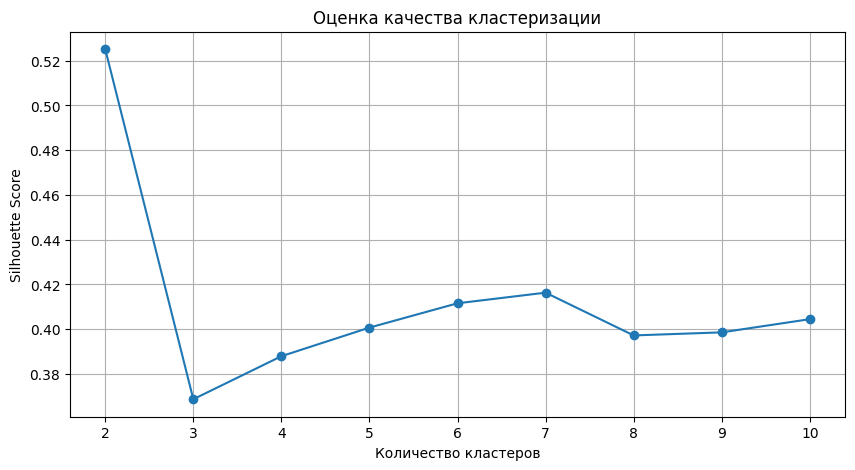

Оптимальное число кластеров: 2
Silhouette Score: 0.5250967623229846


In [3]:
X = grid[feature_columns].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []

max_clusters = min(10, len(X) - 1)

for k in range(2, max_clusters + 1):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    range(2, max_clusters + 1),
    inertia,
    marker="o"
)
ax.set_xlabel("Количество кластеров")
ax.set_ylabel("Inertia")
ax.set_title("Метод локтя")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    range(2, max_clusters + 1),
    silhouette_scores,
    marker="o"
)
ax.set_xlabel("Количество кластеров")
ax.set_ylabel("Silhouette Score")
ax.set_title("Оценка качества кластеризации")
ax.grid(True)
plt.show()

best_k = range(2, max_clusters + 1)[
    np.argmax(silhouette_scores)
]

print("Оптимальное число кластеров:", best_k)
print("Silhouette Score:", max(silhouette_scores))

### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

In [4]:
!pip -q install hdbscan

from hdbscan import HDBSCAN

cluster_results = {}
cluster_metrics = []

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_results["K-Means"] = kmeans.fit_predict(X_scaled)

agglomerative = AgglomerativeClustering(
    n_clusters=best_k
)

cluster_results["Agglomerative"] = agglomerative.fit_predict(X_scaled)

spectral = SpectralClustering(
    n_clusters=best_k,
    random_state=42,
    affinity="nearest_neighbors"
)

cluster_results["Spectral"] = spectral.fit_predict(X_scaled)

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

cluster_results["DBSCAN"] = dbscan.fit_predict(X_scaled)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

cluster_results["HDBSCAN"] = hdbscan_model.fit_predict(X_scaled)

for name, labels in cluster_results.items():

    mask = labels != -1

    if len(set(labels[mask])) >= 2:
        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        davies = davies_bouldin_score(
            X_scaled[mask],
            labels[mask]
        )

        calinski = calinski_harabasz_score(
            X_scaled[mask],
            labels[mask]
        )
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    cluster_metrics.append([
        name,
        len(set(labels)) - (1 if -1 in labels else 0),
        (labels == -1).sum(),
        silhouette,
        davies,
        calinski
    ])

cluster_metrics_df = pd.DataFrame(
    cluster_metrics,
    columns=[
        "algorithm",
        "clusters",
        "noise_points",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz"
    ]
)

display(
    cluster_metrics_df.sort_values(
        "silhouette",
        ascending=False
    )
)

best_algorithm = cluster_metrics_df.dropna(
    subset=["silhouette"]
).sort_values(
    "silhouette",
    ascending=False
).iloc[0]["algorithm"]

print("Лучший алгоритм:", best_algorithm)

grid["cluster"] = cluster_results[best_algorithm]

,algorithm,clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
1,Agglomerative,2,0,0.559518,1.247449,303.727673
4,HDBSCAN,18,334,0.548572,0.808613,385.709005
0,K-Means,2,0,0.525097,1.161396,353.274872
2,Spectral,2,0,0.015181,1.232448,71.527089
3,DBSCAN,1,74,NaN,NaN,NaN


Лучший алгоритм: Agglomerative


### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap
- Постройте тепловые карты средних значений экологических факторов для каждого кластера
- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве
- Проанализируйте профили кластеров и составьте их экологические характеристики
- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

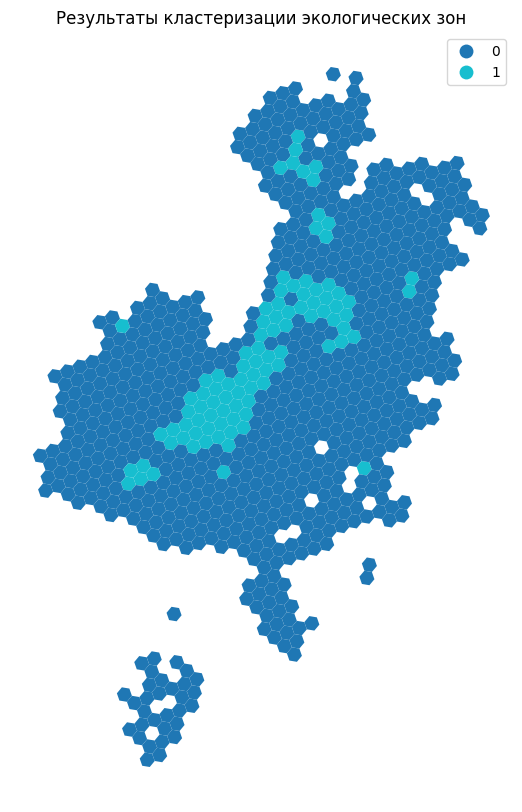

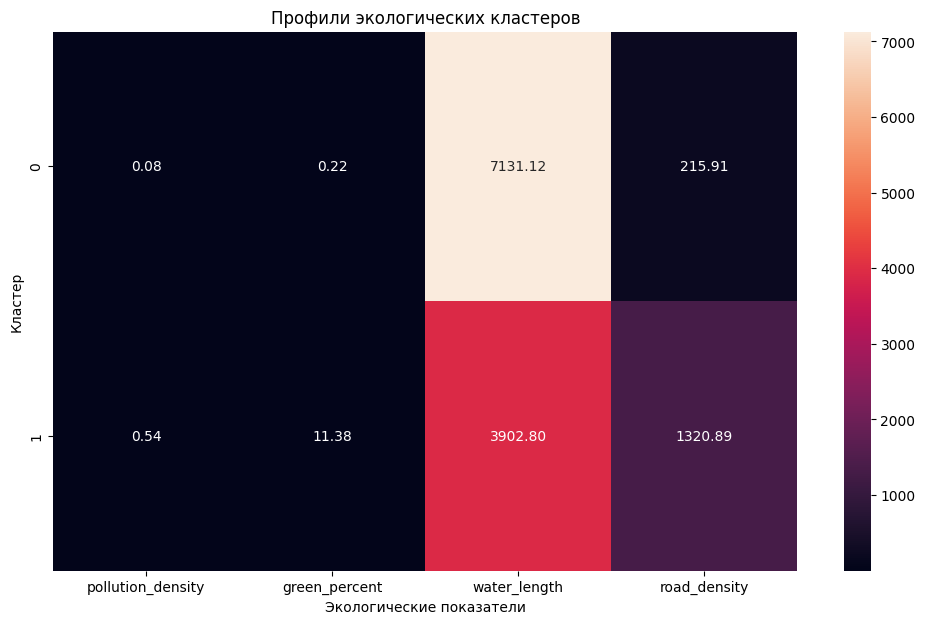

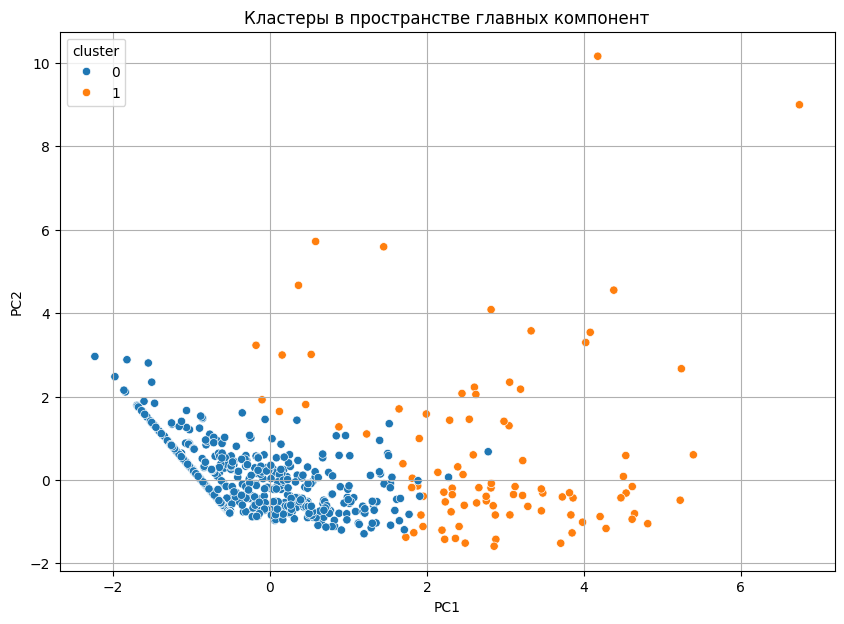

,pollution_density,green_percent,water_length,road_density
cluster,,,,
0,0.08,0.22,7131.12,215.91
1,0.54,11.38,3902.80,1320.89


Характеристики кластеров:

Кластер 0
Загрязнение: 0.08
Зеленые территории: 0.22
Водные объекты: 7131.12
Плотность дорог: 215.91

Кластер 1
Загрязнение: 0.54
Зеленые территории: 11.38
Водные объекты: 3902.8
Плотность дорог: 1320.89


In [5]:
fig, ax = plt.subplots(figsize=(12, 10))

grid.plot(
    column="cluster",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title(
    "Результаты кластеризации экологических зон"
)

ax.set_axis_off()
plt.show()

cluster_profile = grid.groupby("cluster")[
    feature_columns
].mean()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f"
)

plt.title("Профили экологических кластеров")
plt.xlabel("Экологические показатели")
plt.ylabel("Кластер")
plt.show()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = grid["cluster"].values

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10"
)

plt.title("Кластеры в пространстве главных компонент")
plt.grid(True)
plt.show()

display(
    cluster_profile.round(2)
)

print("Характеристики кластеров:")

for cluster in sorted(grid["cluster"].unique()):

    profile = cluster_profile.loc[cluster]

    print()
    print("Кластер", cluster)

    print(
        "Загрязнение:",
        round(profile["pollution_density"], 2)
    )

    print(
        "Зеленые территории:",
        round(profile["green_percent"], 2)
    )

    print(
        "Водные объекты:",
        round(profile["water_length"], 2)
    )

    print(
        "Плотность дорог:",
        round(profile["road_density"], 2)
    )

### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей
- Оцените качество моделей с использованием кросс-валидации
- Выберите оптимальную модель и сохраните её для дальнейшего использования

In [6]:
data = grid[feature_columns + ["cluster"]].copy()

data = data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

X = data[feature_columns]
y = data["cluster"]

print("Распределение классов:")
print(y.value_counts())

if y.nunique() >= 2:

    class_counts = y.value_counts()

    if class_counts.min() >= 2:

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.25,
            random_state=42,
            stratify=y
        )

        models = {
            "LogisticRegression": make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=2000
                )
            ),

            "DecisionTree": DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            ),

            "RandomForest": RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ),

            "GradientBoosting": GradientBoostingClassifier(
                random_state=42
            ),

            "SVM": make_pipeline(
                StandardScaler(),
                SVC()
            ),

            "KNN": make_pipeline(
                StandardScaler(),
                KNeighborsClassifier(
                    n_neighbors=5
                )
            )
        }

        results = []

        for name, model in models.items():

            model.fit(
                X_train,
                y_train
            )

            prediction = model.predict(X_test)

            accuracy = accuracy_score(
                y_test,
                prediction
            )

            precision = precision_score(
                y_test,
                prediction,
                average="weighted",
                zero_division=0
            )

            recall = recall_score(
                y_test,
                prediction,
                average="weighted",
                zero_division=0
            )

            f1 = f1_score(
                y_test,
                prediction,
                average="weighted",
                zero_division=0
            )

            cv_scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring="accuracy"
            )

            results.append([
                name,
                accuracy,
                precision,
                recall,
                f1,
                cv_scores.mean()
            ])

        results_df = pd.DataFrame(
            results,
            columns=[
                "model",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "cv_accuracy"
            ]
        )

        display(
            results_df.sort_values(
                "cv_accuracy",
                ascending=False
            )
        )

        best_model_name = results_df.sort_values(
            "cv_accuracy",
            ascending=False
        ).iloc[0]["model"]

        best_model = models[best_model_name]

        best_model.fit(
            X,
            y
        )

        import joblib

        joblib.dump(
            best_model,
            "best_ecological_model.pkl"
        )

        print(
            "Сохранена модель:",
            best_model_name
        )

    else:

        print(
            "Недостаточно объектов в одном из классов "
            "для стратифицированного обучения."
        )

else:

    print(
        "Классификация невозможна: "
        "обнаружен только один класс."
    )

Распределение классов:
cluster
0    716
1     94
Name: count, dtype: int64


,model,accuracy,precision,recall,f1,cv_accuracy
4,SVM,0.995074,0.995101,0.995074,0.995028,0.995062
2,RandomForest,1.000000,1.000000,1.000000,1.000000,0.990123
5,KNN,0.995074,0.995101,0.995074,0.995028,0.990123
3,GradientBoosting,0.990148,0.990906,0.990148,0.990317,0.986420
1,DecisionTree,1.000000,1.000000,1.000000,1.000000,0.985185
0,LogisticRegression,0.970443,0.971402,0.970443,0.968576,0.983951


Сохранена модель: SVM


## **Требования к отчету (Структуре блокнота)**



1. Описание выбранной территории и источников данных
2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов
3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма
4. Карты распределения экологических факторов и результатов кластеризации
5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию
6. Анализ эффективности разработанных моделей классификации
7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов